--- 1. Cleaned Dataset Structure ---
<class 'pandas.DataFrame'>
RangeIndex: 276693 entries, 0 to 276692
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   listing_id            276693 non-null  int64  
 1   city                  276693 non-null  str    
 2   room_type             276693 non-null  str    
 3   price                 276693 non-null  int64  
 4   minimum_nights        276693 non-null  int64  
 5   latitude              276693 non-null  float64
 6   longitude             276693 non-null  float64
 7   review_scores_rating  276693 non-null  float64
dtypes: float64(3), int64(3), str(2)
memory usage: 16.9 MB
None

--- 2. General Descriptive Statistics ---
               price  minimum_nights  review_scores_rating
count  276693.000000   276693.000000         276693.000000
mean      431.299610        7.743940             63.147651
std       728.347583       20.259761             44.481986
m

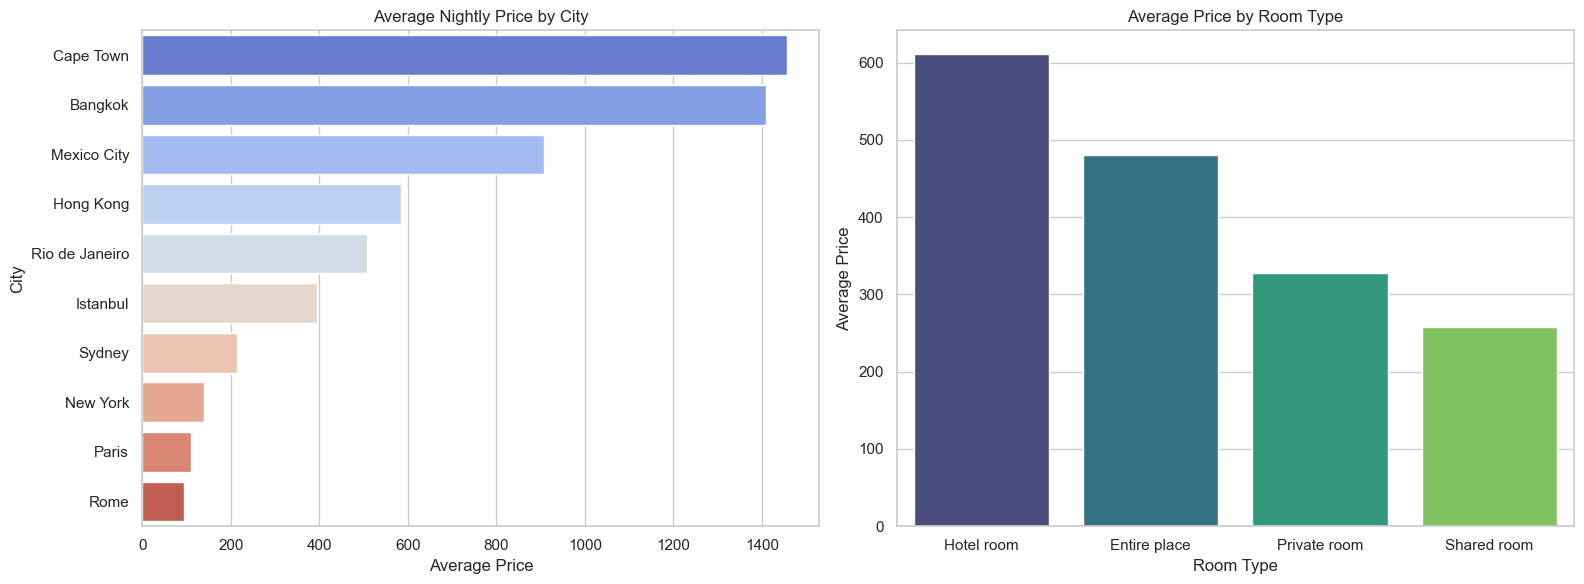

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

listings = pd.read_csv("../data/cleaned/listings_clean.csv")

print("--- 1. Cleaned Dataset Structure ---")
print(listings.info())

print("\n--- 2. General Descriptive Statistics ---")
print(listings[['price', 'minimum_nights', 'review_scores_rating']].describe())

print("\n--- 3. Top Cities by Average Rental Price ---")
avg_price_city = listings.groupby('city')['price'].mean().sort_values(ascending=False)
print(avg_price_city)

print("\n--- 4. Average Price by Room Type ---")
avg_price_room = listings.groupby('room_type')['price'].mean().sort_values(ascending=False)
print(avg_price_room)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(ax=axes[0], x=avg_price_city.values, y=avg_price_city.index, hue=avg_price_city.index, legend=False, palette="coolwarm")
axes[0].set_title("Average Nightly Price by City")
axes[0].set_xlabel("Average Price")
axes[0].set_ylabel("City")

sns.barplot(ax=axes[1], x=avg_price_room.index, y=avg_price_room.values, hue=avg_price_room.index, legend=False, palette="viridis")
axes[1].set_title("Average Price by Room Type")
axes[1].set_xlabel("Room Type")
axes[1].set_ylabel("Average Price")

plt.tight_layout()
plt.show()